In [4]:
from src.live_image_utils import extract_tracks, collect_nuclei_data

In [3]:
from src.utils import extract_wells_info

In [2]:
import sys
sys.path.append('..')

In [5]:
from pathlib import Path
import pandas as pd
import os
import re

In [6]:
path = '/mnt/data/2024-11-15-zkorwek--live'#'/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus--GasED/live'#/mnt/data/2024-10-08-zkorwek--live'

In [10]:
folder_path = Path(path)
pred_list = []
for well_path in folder_path.rglob('*-ST*'):
    well_df =pd.read_csv(well_path/'predictions.csv')
    well_df['well'] = str(well_path).split('/')[-1].split('-')[0]
    pred_list.append(well_df)
    print(well_path)
wells_info = extract_wells_info(path)

/mnt/data/2024-11-15-zkorwek--live/0202-ST
/mnt/data/2024-11-15-zkorwek--live/0203-ST
/mnt/data/2024-11-15-zkorwek--live/0204-ST
/mnt/data/2024-11-15-zkorwek--live/0206-ST
/mnt/data/2024-11-15-zkorwek--live/0302-ST
/mnt/data/2024-11-15-zkorwek--live/0303-ST
/mnt/data/2024-11-15-zkorwek--live/0304-ST
/mnt/data/2024-11-15-zkorwek--live/0306-ST


In [9]:
wells_info

,,,well,Virus,CellType1,CellType2,experiment
0,2,2,0202,mock,A549 WT H2B-miRFP703,mock,/mnt/data/2024-11-15-zkorwek--live
1,2,3,0203,"IAV 0,1 MS5",A549 WT H2B-miRFP703,mock,/mnt/data/2024-11-15-zkorwek--live
2,2,4,0204,"IAV 0,1 MS5",A549 WT H2B-miRFP703,NK 1:1,/mnt/data/2024-11-15-zkorwek--live
3,2,6,0206,mock,A549 WT H2B-miRFP703,NK 1:1,/mnt/data/2024-11-15-zkorwek--live
4,3,2,0302,mock,A549 IFNGR KO H2B-miRFP703,mock,/mnt/data/2024-11-15-zkorwek--live
5,3,3,0303,"IAV 0,1 MS5",A549 IFNGR KO H2B-miRFP703,mock,/mnt/data/2024-11-15-zkorwek--live
6,3,4,0304,"IAV 0,1 MS5",A549 IFNGR KO H2B-miRFP703,NK 1:1,/mnt/data/2024-11-15-zkorwek--live
7,3,6,0306,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1,/mnt/data/2024-11-15-zkorwek--live


1726919
1904410
1809051
1832347
1725982
1760135
1668486
1683520


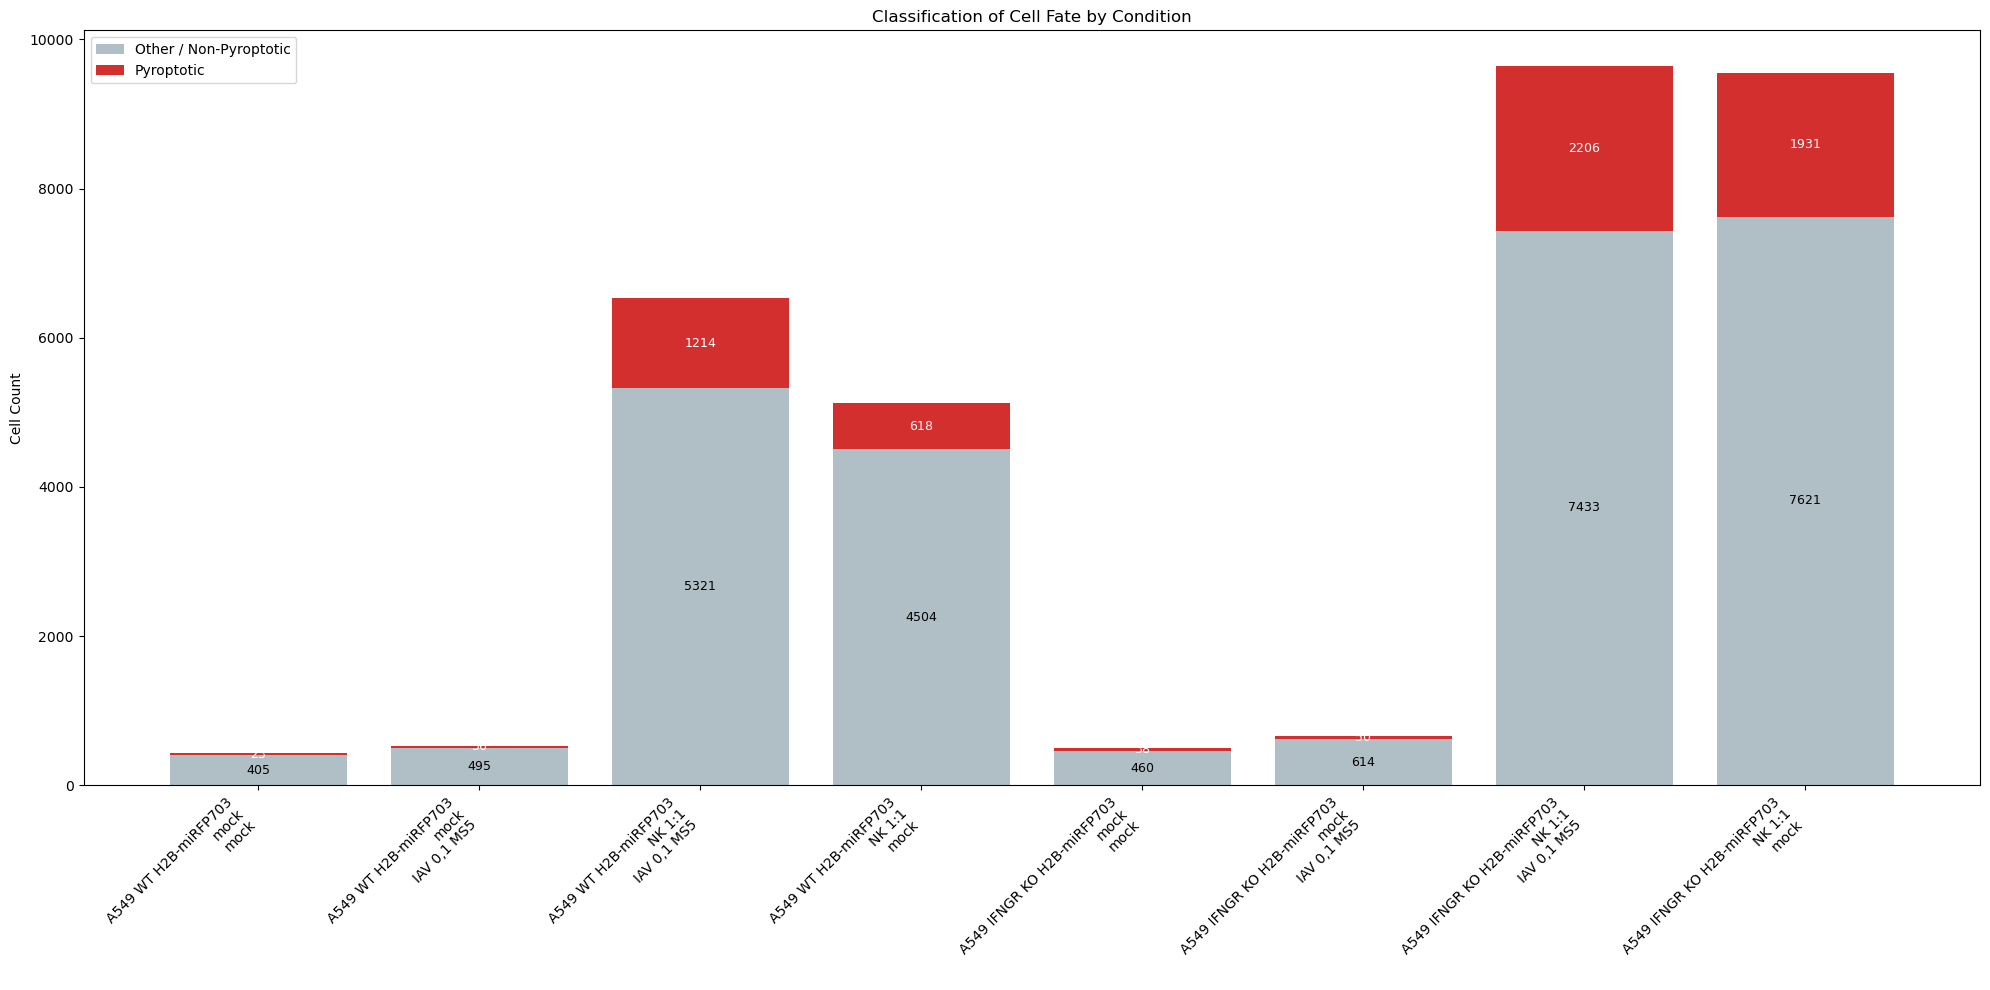

In [12]:
summary_data = []
# Iterate through wells_info and the corresponding prediction dataframe simultaneously
# Assuming pred_list is ordered matching the rows of wells_info
df = pd.concat(pred_list)
df = df.merge(wells_info, left_on='well', right_on='well')
for well, pred_df in df.groupby('well'):
    row = pred_df.iloc[0]
    # ---------------------------------------------------------
    # 2. Define Identifiers and Paths
    # ---------------------------------------------------------
    # Create the label for the X-axis
    # Adjust column names if your actual DF headers differ
    label = f"{row['CellType1']}\n{row['CellType2']}\n{row['Virus']}"#f"{row['Cell Type']}\n{row['Compound']}"#
    
    # Extract the well ID for the file path. 
    # NOTE: Based on your text, '0202' appeared under 'CellType1' or was the 3rd value. 
    # Please ensure 'well_id' variable gets the '0202', '0203' string.
    # If the column named 'well' contains '2' but you need '0202', use the column that has '0202'.
    # Here I assume the column acting as the ID is the one containing '0202'.
    well_id = row['well'] if len(str(row['well'])) == 4 else row['CellType1'] 
    
    # Construct path: experiment_path/{well}-ST/tracks_pi.csv
    base_path = row['experiment']
    tracks_path = os.path.join(base_path, f"{well_id}-ST", "tracks_pi.csv")
    print(len(pred_df))
    # ---------------------------------------------------------
    # 3. Load and Merge Data
    # ---------------------------------------------------------
    try:
        tracks_df = pd.read_csv(tracks_path).rename({'nucleus_index':'nucleus_id'},axis=1)
    except FileNotFoundError:
        print(f"File not found: {tracks_path}")
        continue
    
    # Standardize column names for merging
    # Map whatever ID column exists to 'track_id'
    track_id_col_t = 'track_index'#'nucleus_id' if 'nucleus_id' in tracks_df.columns else 'nucleus_index'
    track_id_col_p = 'track_index'#'nucleus_id' if 'nucleus_id' in pred_df.columns else 'nucleus_index'
    
    # Merge tracks with predictions on track_id and time_point_index
    # We use inner join to ensure we only analyze tracks we have predictions for
    merged_df = pd.merge(tracks_df, pred_df, on=['nucleus_id', 'time_point_index'], how='inner')

    # ---------------------------------------------------------
    # 4. Filter and Classify
    # ---------------------------------------------------------
    # Calculate length of each track (number of time points)
    track_lengths = merged_df.groupby('track_index').size()
    
    # Filter: Keep only tracks longer than n=5
    long_track_ids = track_lengths[track_lengths > 10].index
    valid_data = merged_df[merged_df['track_index'].isin(long_track_ids)]

    # Group by track and find the maximum prediction score for each track
    # If max score > 0.5, the cell is considered Pyroptotic
    track_max_scores = valid_data.groupby('track_index')['prediction'].max()
    threshold = 0.5
    pyroptotic_count = (track_max_scores > threshold).sum()
    non_pyroptotic_count = (track_max_scores <= threshold).sum()
    summary_data.append({
        'Label': label,
        'Pyroptotic': pyroptotic_count,
        'Other': non_pyroptotic_count
    })

import matplotlib.pyplot as plt
import pandas as pd

# Convert the list of dictionaries to a DataFrame
plot_df = pd.DataFrame(summary_data)

if not plot_df.empty:
    # Set up the figure size (adjust width based on number of samples)
    plt.figure(figsize=(20,10))
    
    # Create the stacked bars
    # 1. Plot the "Other" (Non-Pyroptotic) bars at the bottom
    p1 = plt.bar(plot_df['Label'], plot_df['Other'], 
                 color='#B0BEC5', label='Other / Non-Pyroptotic') # Grey/Blue color
    
    # 2. Plot the "Pyroptotic" bars on top (using 'bottom' parameter)
    p2 = plt.bar(plot_df['Label'], plot_df['Pyroptotic'], 
                 bottom=plot_df['Other'], 
                 color='#D32F2F', label='Pyroptotic') # Red color
    
    # Formatting the plot
    plt.ylabel('Cell Count')
    plt.title('Classification of Cell Fate by Condition')
    plt.legend()
    
    # Rotate x-axis labels if they overlap
    plt.xticks(rotation=45, ha='right')
    
    # Optional: Add text labels on the bars
    for i, row in plot_df.iterrows():
        # Label for Other (bottom bar)
        if row['Other'] > 0:
            plt.text(i, row['Other']/2, str(row['Other']), 
                     ha='center', va='center', color='black', fontsize=9)
        # Label for Pyroptotic (top bar)
        if row['Pyroptotic'] > 0:
            plt.text(i, row['Other'] + row['Pyroptotic']/2, str(row['Pyroptotic']), 
                     ha='center', va='center', color='white', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")


In [34]:
wells_info# = extract_wells_info(path)

,,,well,Cell Type,Compound,experiment
0,2,2,0202,A549WT,mock,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
1,2,3,0203,A549WT,IAV MS4 MOI 1,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
2,2,4,0204,A549WT,"pIC 0,1",/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
3,2,5,0205,A549WT,Cisplatin 10mM,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
4,2,6,0206,A549WT,NK 1:1,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
5,3,2,0302,A549 GasD KO,mock,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
6,3,3,0303,A549 GasD KO,IAV MS4 MOI 1,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
7,3,4,0304,A549 GasD KO,"pIC 0,1",/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
8,3,5,0305,A549 GasD KO,Cisplatin 10uM,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...
9,3,6,0306,A549 GasD KO,NK 1:1,/mnt/nas/group/REPORT/Imaging/2025-09-09-wprus...


In [24]:
len(pred_list)

15

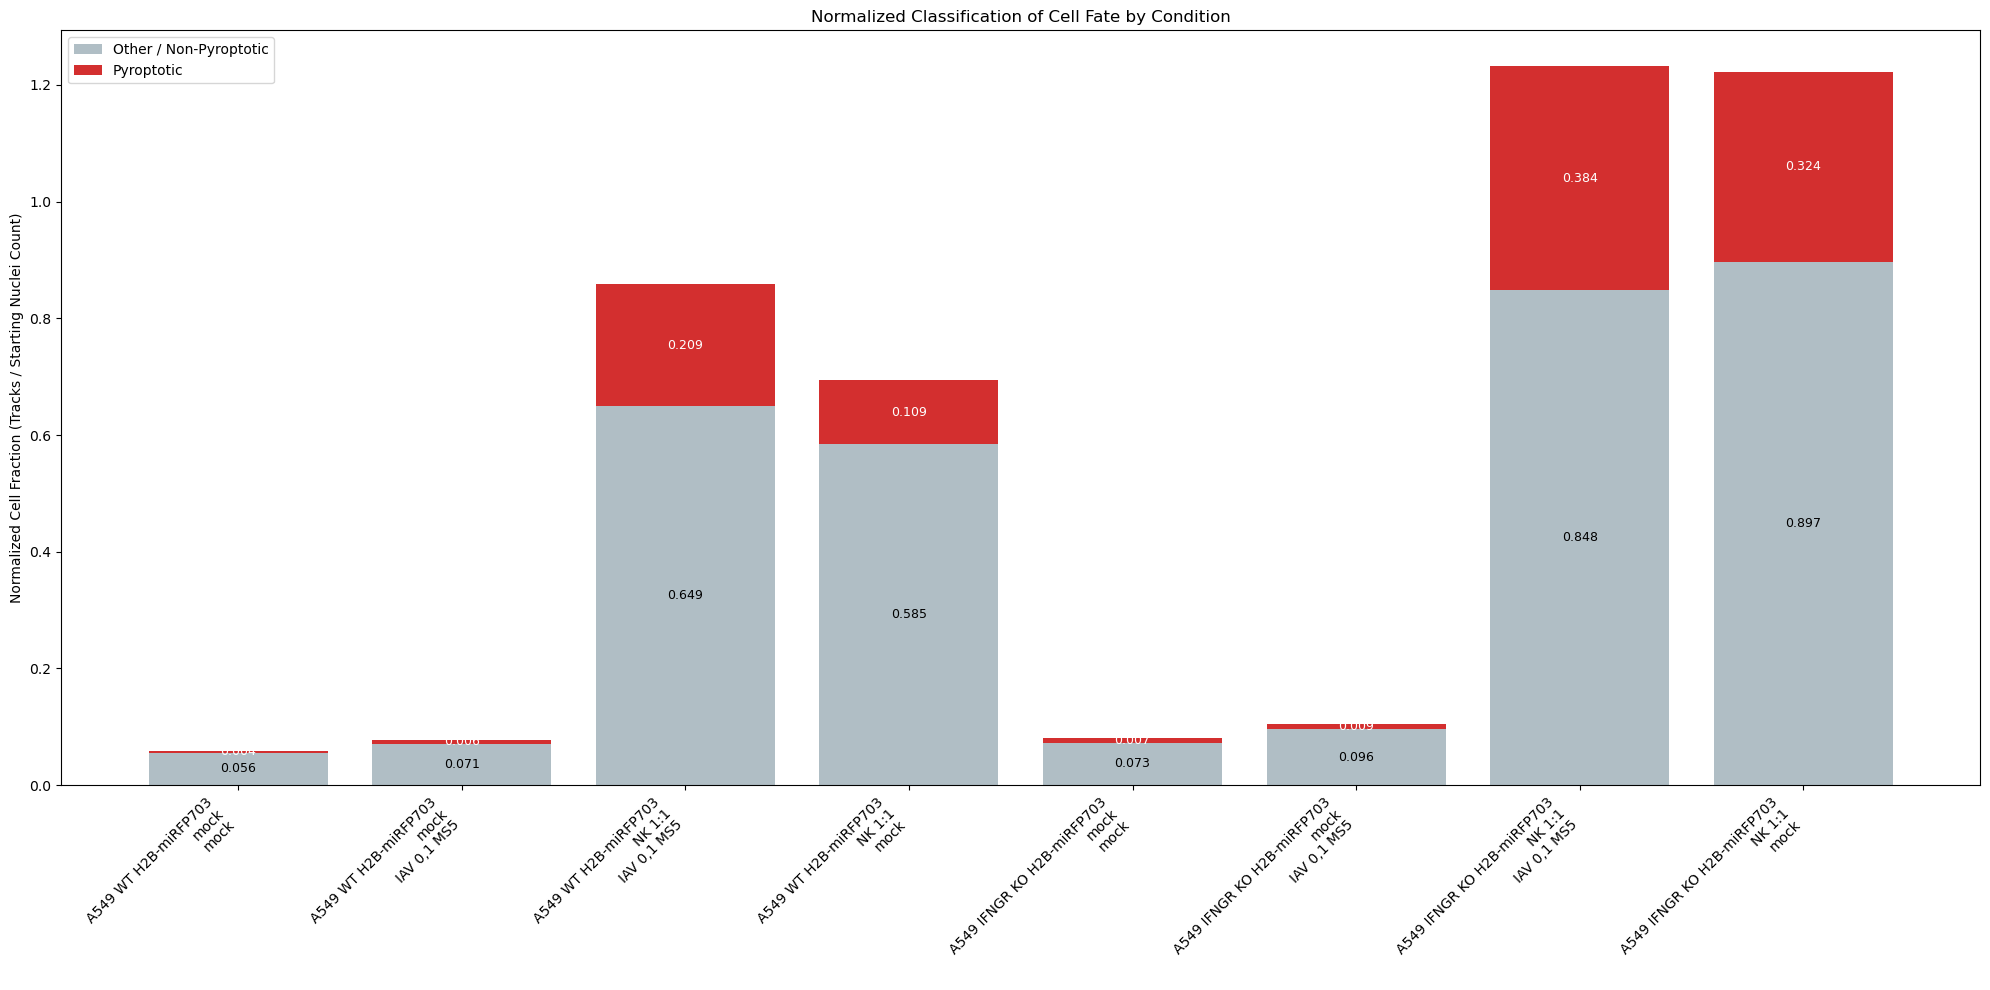

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. PRE-COMPUTE NUCLEI COUNTS ---
# Get all unique experiment root paths from your wells_info to run the collection
unique_experiments = wells_info['experiment'].unique()
all_nuclei_data =[]

for exp in unique_experiments:
    # Uses your provided function to parse the text files
    exp_nuclei_df = collect_nuclei_data(exp)
    all_nuclei_data.append(exp_nuclei_df)

if all_nuclei_data:
    all_nuclei_df = pd.concat(all_nuclei_data, ignore_index=True)
    # Ensure the well identifier is a string so it matches `well_id` later
    all_nuclei_df['well'] = all_nuclei_df['well'].astype(str)
    # Sort for merge_asof which we'll use to automatically forward-fill missing timepoints
    all_nuclei_df = all_nuclei_df.sort_values(['experiment', 'well', 'time_point_index'])
else:
    all_nuclei_df = pd.DataFrame(columns=['well', 'experiment', 'time_point_index', 'nuclei_number'])


# --- 2. CLASSIFICATION & NORMALIZATION LOOP ---
summary_data =[]

# Iterate through wells_info and the corresponding prediction dataframe simultaneously
for well, pred_df in df.groupby('well'):
    row = pred_df.iloc[0]
    label = f"{row['Cell Type']}\n{row['Compound']}"#f"{row['CellType1']}\n{row['CellType2']}\n{row['Virus']}"#
    # Extract the well ID
    well_id = str(row['well'] if len(str(row['well'])) == 4 else row['CellType1'])
    
    base_path = row['experiment']
    tracks_path = os.path.join(base_path, f"{well_id}-ST", "tracks_pi.csv")
    
    try:
        tracks_df = pd.read_csv(tracks_path).rename({'nucleus_index':'nucleus_id'}, axis=1)
    except FileNotFoundError:
        print(f"File not found: {tracks_path}")
        continue
    
    merged_df = pd.merge(tracks_df, pred_df, on=['nucleus_id', 'time_point_index'], how='inner')

    # Calculate length of each track
    track_lengths = merged_df.groupby('track_index').size()
    
    # Filter: Keep only tracks longer than n=10
    long_track_ids = track_lengths[track_lengths > 20].index
    valid_data = merged_df[merged_df['track_index'].isin(long_track_ids)]
    
    if valid_data.empty:
        continue

    # Get max prediction score per track
    track_max_scores = valid_data.groupby('track_index')['prediction'].max().reset_index()
    
    # --- WEIGHT CALCULATION ---
    # Find the starting timepoint of each track
    track_starts = valid_data.groupby('track_index')['time_point_index'].min().reset_index()
    track_starts = track_starts.sort_values('time_point_index')
    
    # Filter the nuclei counts for the current experiment and well
    well_nuclei = all_nuclei_df[(all_nuclei_df['experiment'] == base_path) & 
                                (all_nuclei_df['well'] == well_id)].copy()
    
    if not well_nuclei.empty:
        well_nuclei = well_nuclei.sort_values('time_point_index')
        
        # merge_asof with direction='backward' behaves exactly like a forward-fill. 
        # If a track starts at an unrecorded timepoint, it grabs the last known previous measurement.
        track_info = pd.merge_asof(track_starts, 
                                   well_nuclei[['time_point_index', 'nuclei_number']], 
                                   on='time_point_index', 
                                   direction='backward')
        
        # If a track starts before the very first nuclei file, fallback to backward fill
        track_info['nuclei_number'] = track_info['nuclei_number'].bfill()
        
        # Apply the weight: 1 / nuclei_number (protect against div by 0 just in case)
        track_info['weight'] = track_info['nuclei_number'].apply(lambda x: 1.0 / x if pd.notnull(x) and x > 0 else 0.0)
    else:
        # Fallback if no nuclei file was found for this well
        track_info = track_starts.copy()
        track_info['weight'] = 1.0 
        
    # Merge the individual track weights back to their prediction max scores
    track_summary = pd.merge(track_max_scores, track_info[['track_index', 'weight']], on='track_index')

    threshold = 0.5
    
    # Instead of counting (.sum() on boolean), sum the normalized weights
    pyroptotic_weight = track_summary[track_summary['prediction'] > threshold]['weight'].sum()
    non_pyroptotic_weight = track_summary[track_summary['prediction'] <= threshold]['weight'].sum()
    
    summary_data.append({
        'Label': label,
        'Pyroptotic': pyroptotic_weight,
        'Other': non_pyroptotic_weight
    })
# Convert the list of dictionaries to a DataFrame
plot_df = pd.DataFrame(summary_data)

if not plot_df.empty:
    plt.figure(figsize=(20,10))
    
    # 1. Plot the "Other" (Non-Pyroptotic) bars at the bottom
    p1 = plt.bar(plot_df['Label'], plot_df['Other'], 
                 color='#B0BEC5', label='Other / Non-Pyroptotic') 
    
    # 2. Plot the "Pyroptotic" bars on top
    p2 = plt.bar(plot_df['Label'], plot_df['Pyroptotic'], 
                 bottom=plot_df['Other'], 
                 color='#D32F2F', label='Pyroptotic') 
    
    # Formatting the plot
    plt.ylabel('Normalized Cell Fraction (Tracks / Starting Nuclei Count)')
    plt.title('Normalized Classification of Cell Fate by Condition')
    plt.legend()
    
    plt.xticks(rotation=45, ha='right')
    
    # Add text labels on the bars with float formatting
    for i, row in plot_df.iterrows():
        # Label for Other
        if row['Other'] > 0:
            plt.text(i, row['Other']/2, f"{row['Other']:.3f}", 
                     ha='center', va='center', color='black', fontsize=9)
        # Label for Pyroptotic
        if row['Pyroptotic'] > 0:
            plt.text(i, row['Other'] + row['Pyroptotic']/2, f"{row['Pyroptotic']:.3f}", 
                     ha='center', va='center', color='white', fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot.")

<Axes: >

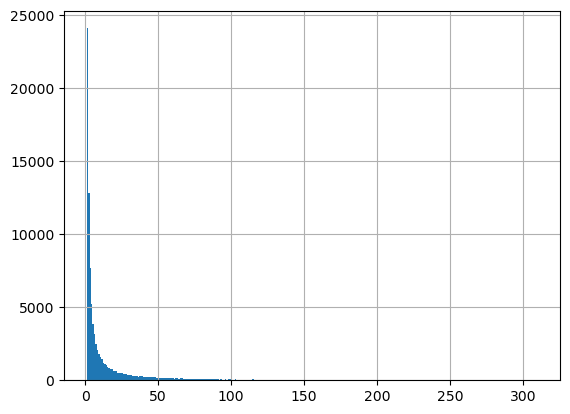

In [76]:
track_max = track_stats.groupby(['well', 'track_index']).max()
track_max.track_length.hist(bins=310)

In [84]:
track_max = track_max.merge(track_stats.groupby(['well', 'track_index'])['time_point_index'].min(), left_index=True, right_index=True, suffixes=['_max', '_min'])

<Axes: >

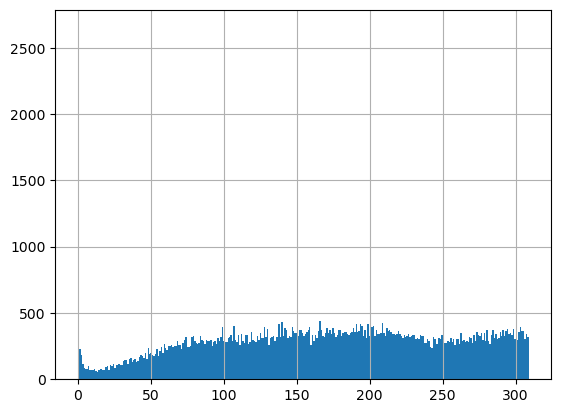

In [ ]:
track_stats.groupby(['well', 'track_index'])['time_point_index'].min()

<Axes: xlabel='prediction', ylabel='track_length'>

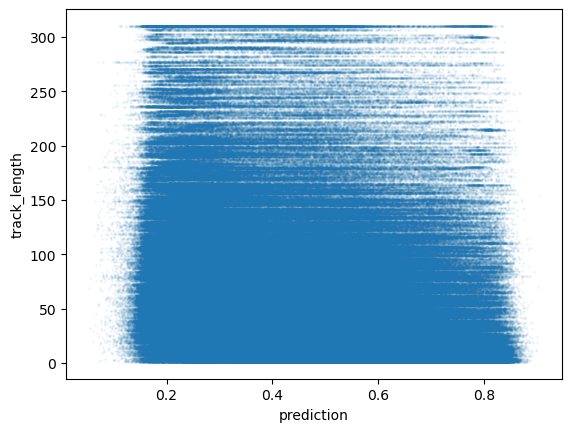

In [22]:
track_stats.plot.scatter(x='prediction', y='track_length', s=1, alpha=0.05)

<Axes: >

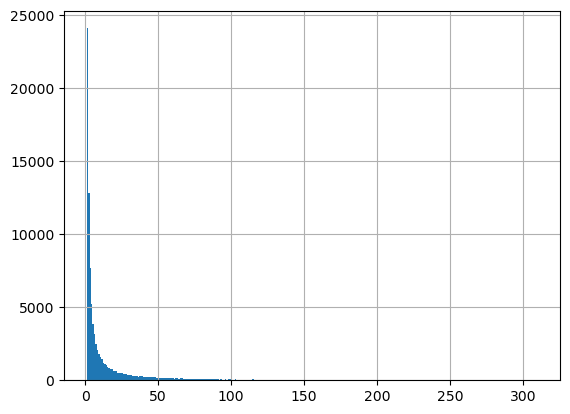

In [28]:
track_max.track_length.hist(bins=310)

<Axes: xlabel='prediction', ylabel='track_length'>

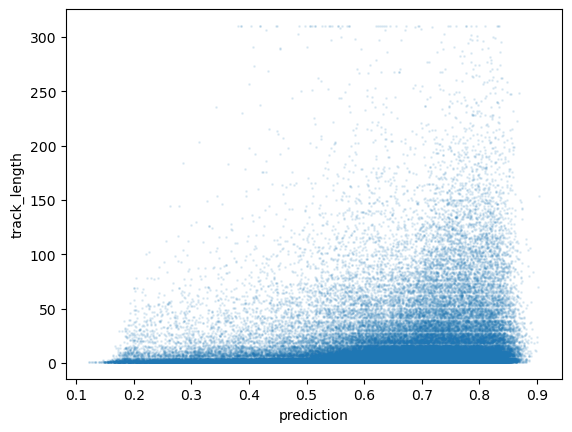

In [32]:
track_max.plot.scatter(x='prediction', y='track_length',s=1, alpha=0.1)

In [25]:
track_stats

,index,track_index,time_point_index,nucleus_id,area,area_masked,eccentricity,is_toggled,center_x,center_y,...,track_length,label,experiment,well,prediction,Row,Column,Virus,CellType1,CellType2
0,0,0,0,368,364.5,0.0,0.056,0,4107.96,276.23,...,310,None,/mnt/data/2024-10-08-zkorwek--live,0202,0.169931,2,2,mock,A549 WT H2B-miRFP703,mock
1,1,0,1,381,378.5,0.0,0.025,0,4107.42,280.12,...,310,None,/mnt/data/2024-10-08-zkorwek--live,0202,0.215482,2,2,mock,A549 WT H2B-miRFP703,mock
2,2,0,2,400,381.0,0.0,0.034,0,4108.01,282.59,...,310,None,/mnt/data/2024-10-08-zkorwek--live,0202,0.206503,2,2,mock,A549 WT H2B-miRFP703,mock
3,3,0,3,405,378.0,0.0,0.023,0,4107.95,286.07,...,310,None,/mnt/data/2024-10-08-zkorwek--live,0202,0.190049,2,2,mock,A549 WT H2B-miRFP703,mock
4,4,0,4,402,380.5,0.0,0.040,0,4107.36,287.22,...,310,None,/mnt/data/2024-10-08-zkorwek--live,0202,0.201729,2,2,mock,A549 WT H2B-miRFP703,mock
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384113,175937,11576,111,35,99.5,0.0,0.127,0,101.31,4674.37,...,1,None,/mnt/data/2024-10-08-zkorwek--live,0306,0.461981,3,6,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1
1384114,175938,11577,1,293,37.0,0.0,0.498,0,1.81,3406.00,...,1,None,/mnt/data/2024-10-08-zkorwek--live,0306,0.584546,3,6,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1
1384115,175939,11578,165,162,108.5,0.0,0.073,0,5228.34,3329.90,...,1,None,/mnt/data/2024-10-08-zkorwek--live,0306,0.635450,3,6,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1
1384116,175940,11579,176,519,94.5,0.0,0.028,0,4403.42,4414.33,...,1,None,/mnt/data/2024-10-08-zkorwek--live,0306,0.653748,3,6,mock,A549 IFNGR KO H2B-miRFP703,NK 1:1


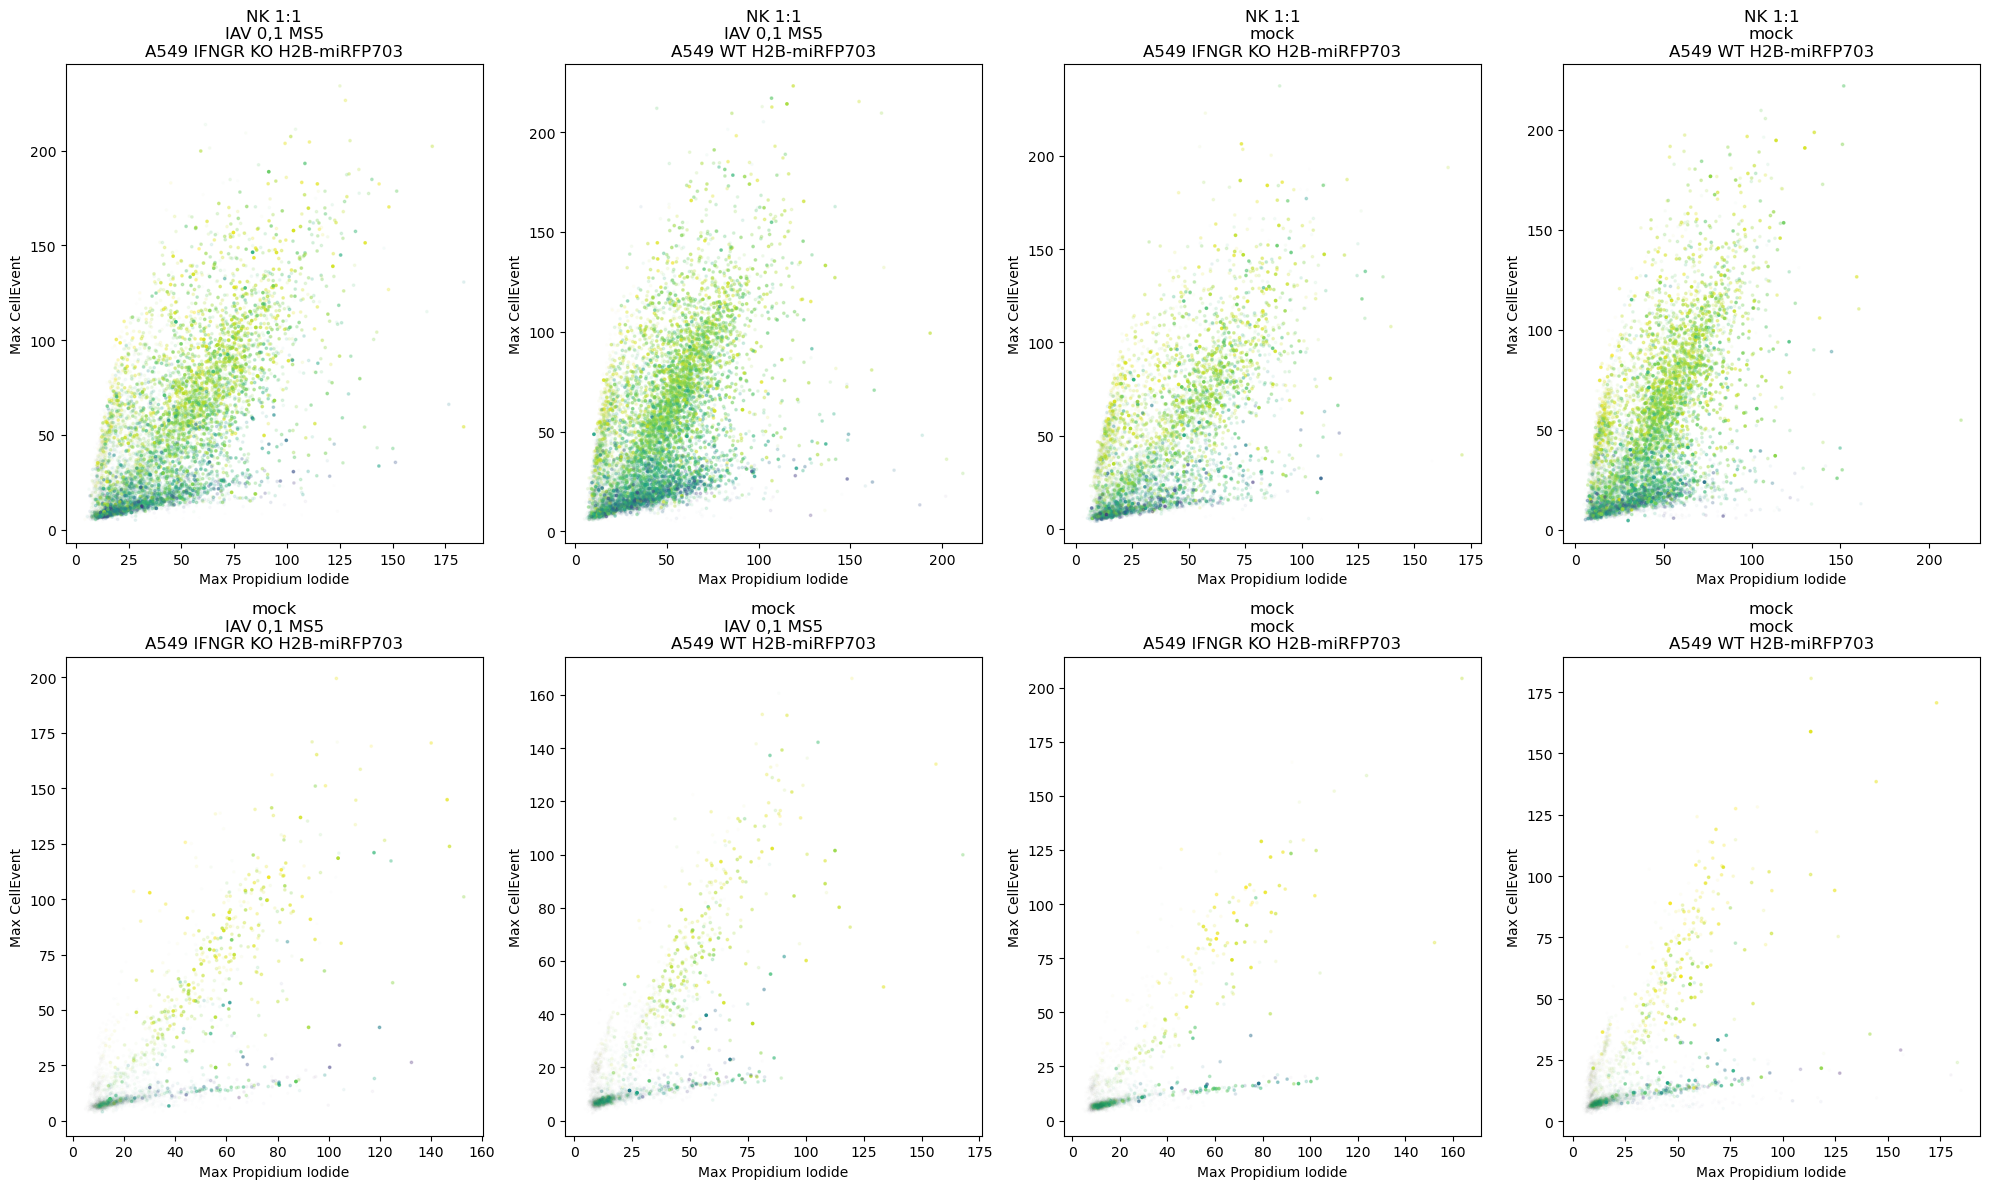

In [99]:
import matplotlib.pyplot as plt
groups = track_stats.sort_values(by=['CellType2', 'Virus'], ascending=False).groupby(['CellType2','Virus','CellType1'])

# Set up a grid for 15 subplots (adjust as needed)
n_groups = len(groups)
ncols = 4
nrows = (n_groups + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20,12))
axes = axes.flatten()

for ax, ((virus, compound, celltype), subdf) in zip(axes, groups):
    start_time = subdf.groupby('track_index')['time_point_index'].min()
    valid_tracks = start_time[start_time != 0].index
    subdf = subdf[subdf['track_index'].isin(valid_tracks)]
    track_max = subdf.groupby('track_index').max()
    
    sc = ax.scatter(
        track_max['pi_intensity_mean'],
        track_max['ce_intensity_mean'],
        c=track_max['prediction'],
        cmap='viridis',
        alpha=track_max['track_length']/310,
        s=3
    )
    ax.set_title(f'{virus}\n{compound}\n{celltype}')
    ax.set_xlabel('Max Propidium Iodide')
    ax.set_ylabel('Max CellEvent')

# Add colorbar for label scale
#fig.colorbar(sc, ax=axes.tolist(), label='Label')

# Hide any unused subplots
for ax in axes[len(groups):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

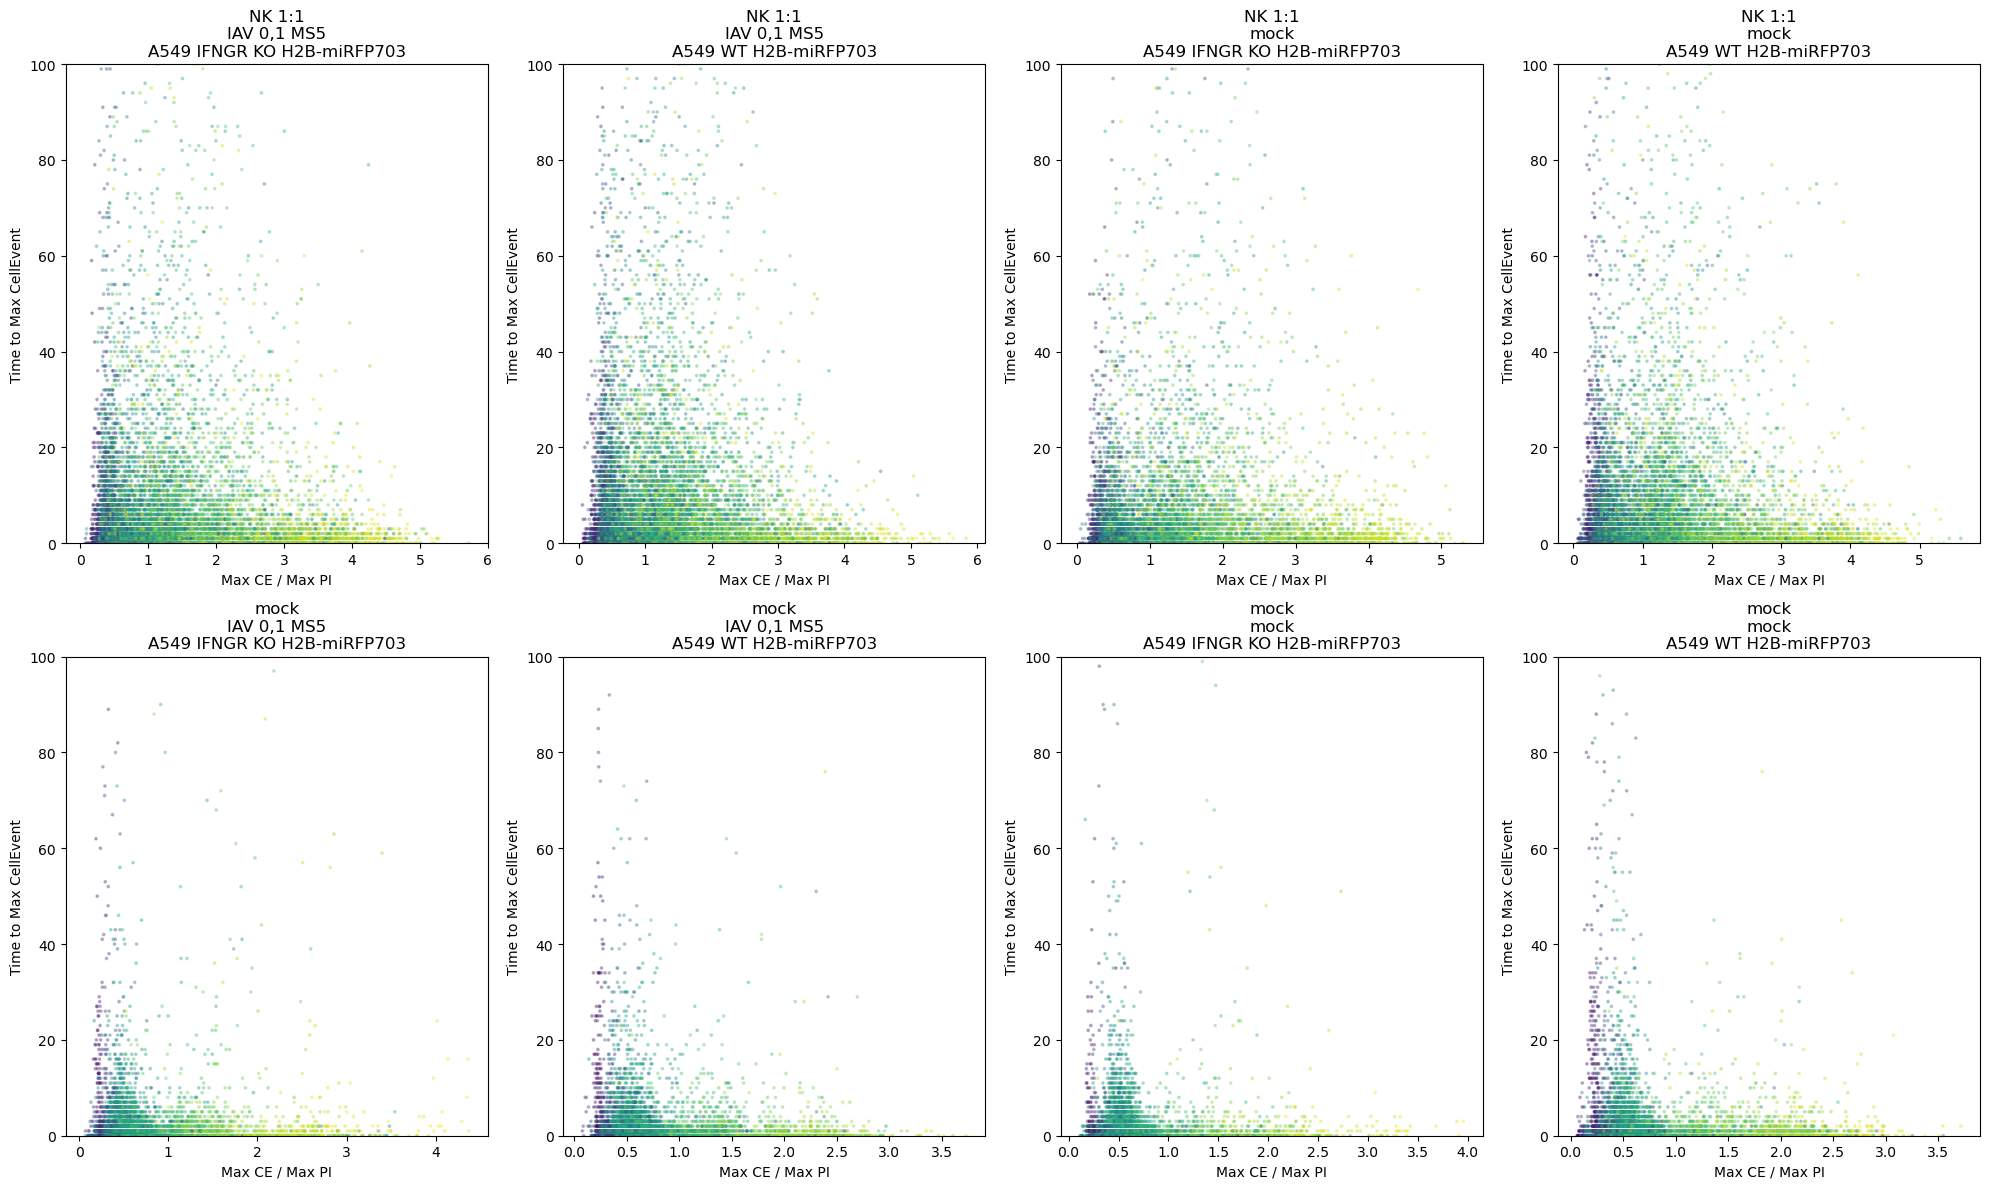

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

groups = (
    track_stats
    .sort_values(by=['CellType2', 'Virus'], ascending=False)
    .groupby(['CellType2','Virus','CellType1'])
)

n_groups = len(groups)
ncols = 4
nrows = (n_groups + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 12))
axes = axes.flatten()

for ax, ((virus, compound, celltype), subdf) in zip(axes, groups):

    # group by track
    g = subdf.groupby('track_index')

    # max values
    max_ce = g['ce_intensity_mean'].max()
    max_pi = g['pi_intensity_mean'].max()

    # time of max CE
    idx_max_ce = g['ce_intensity_mean'].idxmax()
    t_max_ce = subdf.loc[idx_max_ce, 'time_point_index'].values

    # beginning time
    t_start = g['time_point_index'].min().values

    # compute axes
    x = max_ce.values / max_pi.values
    y = t_max_ce - t_start

    # optional coloring (example: prediction at max CE)
    pred = subdf.loc[idx_max_ce, 'prediction'].values

    sc = ax.scatter(
        x,
        y,
        c=pred,
        cmap='viridis',
        alpha=0.3,
        s=3
    )

    ax.set_title(f'{virus}\n{compound}\n{celltype}')
    ax.set_xlabel('Max CE / Max PI')
    ax.set_ylabel('Time to Max CellEvent')
    ax.set_ylim([0,100])

# Hide unused subplots
for ax in axes[len(groups):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


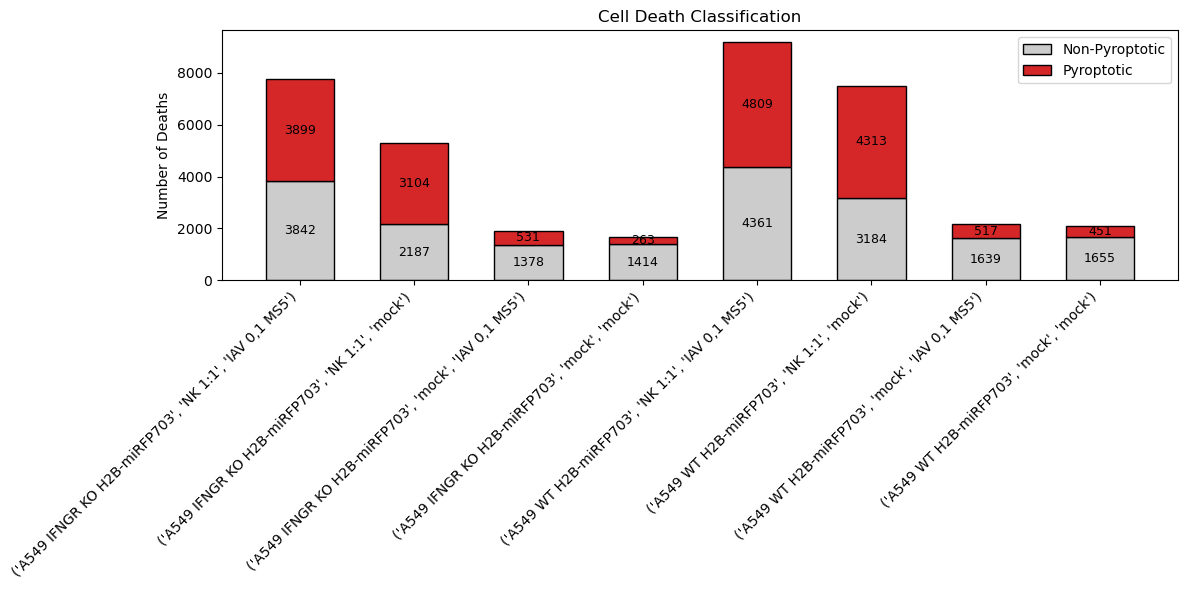

In [68]:




import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
threshold=0.7
# Setup plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.6
l=5

non_pyro = track_max[(track_max.prediction<=threshold)&(track_max.track_length>l)].groupby(['CellType1', 'CellType2', 'Virus'])['time_point_index'].count()
pyro = track_max[(track_max.prediction>threshold)&(track_max.track_length>l)].groupby(['CellType1', 'CellType2', 'Virus'])['time_point_index'].count()
x_pos = np.arange(len(pyro))
# Plot Bottom Bars (Non-Pyroptotic)
p1 = ax.bar(x_pos, non_pyro, bar_width, 
            label='Non-Pyroptotic', color='#cccccc', edgecolor='black')

# Plot Top Bars (Pyroptotic) - stacked on top of Non-Pyroptotic
p2 = ax.bar(x_pos, pyro, bar_width, 
            bottom=non_pyro, 
            label='Pyroptotic', color='#d62728', edgecolor='black')

# Formatting
ax.set_ylabel('Number of Deaths')
ax.set_title('Cell Death Classification')
ax.set_xticks(x_pos)
ax.set_xticklabels(pyro.index, rotation=45, ha='right')
ax.legend()

# Optional: Add counts inside the bars
for bars in [p1, p2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        xytext=(0, 0), textcoords="offset points",
                        ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

In [8]:

tracks = pd.DataFrame()
for name in os.listdir(path):
    print(name)
    subdir = os.path.join(path, name)
    if os.path.isdir(subdir) and re.match(r"\d{4}-ST", subdir.split('/')[-1]):#fullmatch
        
        well_tracks = extract_tracks(subdir)
        preds = pd.read_csv(subdir+'/predictions.csv')
        well_tracks = well_tracks.merge(preds[['nucleus_id', 'prediction', 'time_point_index']], on=['nucleus_id', 'time_point_index'], how='left')
        tracks = pd.concat((tracks, well_tracks), axis=0)

track_stats = pd.merge(tracks.reset_index(), extract_wells_info(path), on=['well', 'experiment'])



0202-ST
0203-ST
0205-ST
0206-ST
0302-ST
0303-ST
0305-ST
0306-ST
2024-10-08-zkorwek--live_1.config
WellsInfo.html
WellsInfo.pkl
tmux-client-9491.log


In [ ]:




import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

df_plot = pd.DataFrame(plot_data).sort_values('Label')

# Setup plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.6
x_pos = np.arange(len(df_plot))


# Plot Bottom Bars (Non-Pyroptotic)
p1 = ax.bar(x_pos, df_plot['Non-Pyroptotic'], bar_width, 
            label='Non-Pyroptotic', color='#cccccc', edgecolor='black')

# Plot Top Bars (Pyroptotic) - stacked on top of Non-Pyroptotic
p2 = ax.bar(x_pos, df_plot['Pyroptotic'], bar_width, 
            bottom=df_plot['Non-Pyroptotic'], 
            label='Pyroptotic', color='#d62728', edgecolor='black')

# Formatting
ax.set_ylabel('Number of Deaths (Tracks > 5 frames)')
ax.set_title('Cell Death Classification by Condition')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_plot['Label'], rotation=45, ha='right')
ax.legend()

# Optional: Add counts inside the bars
for bars in [p1, p2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        xytext=(0, 0), textcoords="offset points",
                        ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

In [91]:
from scipy.optimize import linear_sum_assignment
import itertools as itt
def track_frame(prev_centroids, prev_ids, centroids, track_id_generator, max_distance):
    ''' Match current to previous using Hungarian algorithm '''
    
    thr = np.sqrt(max_distance)

    # compute the sqrt of distance between centroids
    cost_matrix = np.sqrt(np.linalg.norm(
        prev_centroids[:, None, :] - centroids[['x', 'y']].values[None, :, :], axis=2
    ))

    # find mutual nuclei assignment to minimize cost
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    track_ids = np.zeros(len(centroids), dtype=np.int32)
    
    for r, c in zip(row_ind, col_ind):
        if cost_matrix[r, c] < thr:  # filter for max allowed distance
            track_ids[c] = prev_ids[r]

    # assign new track_ids to unassigned objects
    for i in range(len(track_ids)):
        if track_ids[i] == 0:
            track_ids[i] = next(track_id_generator)
    return track_ids

track_id_generator = itt.count(1)
df = track_stats
df['new_track_index'] = -1

for well, well_df in df.groupby('well'):
    well_df = well_df.sort_values('time_point_index')

    track_id_generator = itt.count(1)

    prev_centroids = None
    prev_ids = None

    for t, frame_df in well_df.groupby('time_point_index'):
        idx = frame_df.index

        centroids = frame_df[['center_x', 'center_y']]

        if prev_centroids is None:
            # first frame: assign new IDs
            track_ids = [next(track_id_generator) for _ in range(len(frame_df))]
        else:
            track_ids = track_frame(
                prev_centroids,
                prev_ids,
                frame_df[['center_x', 'center_y']].rename(
                    columns={'center_x': 'x', 'center_y': 'y'}
                ),
                track_id_generator,
                300
            )

        df.loc[idx, 'new_track_index'] = track_ids

        prev_centroids = centroids.values
        prev_ids = np.array(track_ids)


<Axes: >

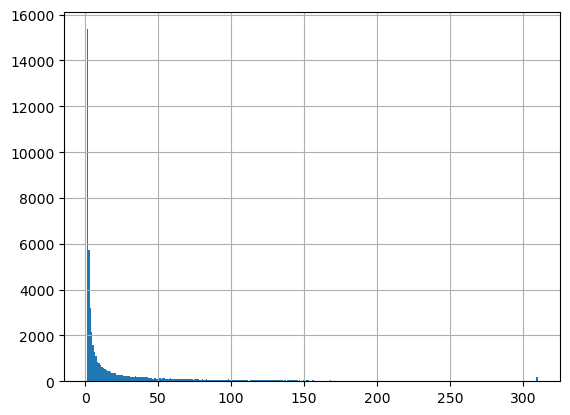

In [95]:
df.groupby(['well', 'new_track_index'])['time_point_index'].size().hist(bins=310)

In [97]:
track_stats['track_index'] = df['new_track_index']

<Axes: >

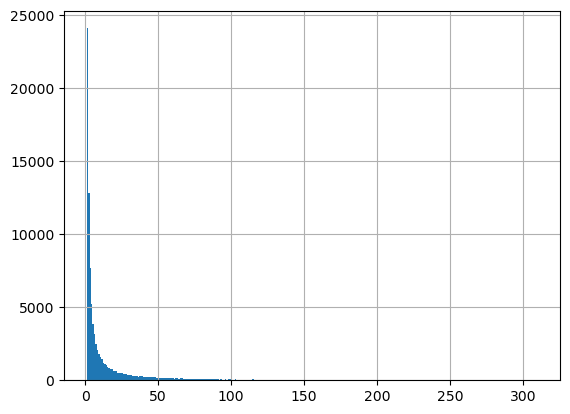

In [ ]:
df.groupby(['well', 'track_index'])['time_point_index'].size().hist(bins=310)